In [2]:
import matplotlib.pyplot as plt
# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 240325

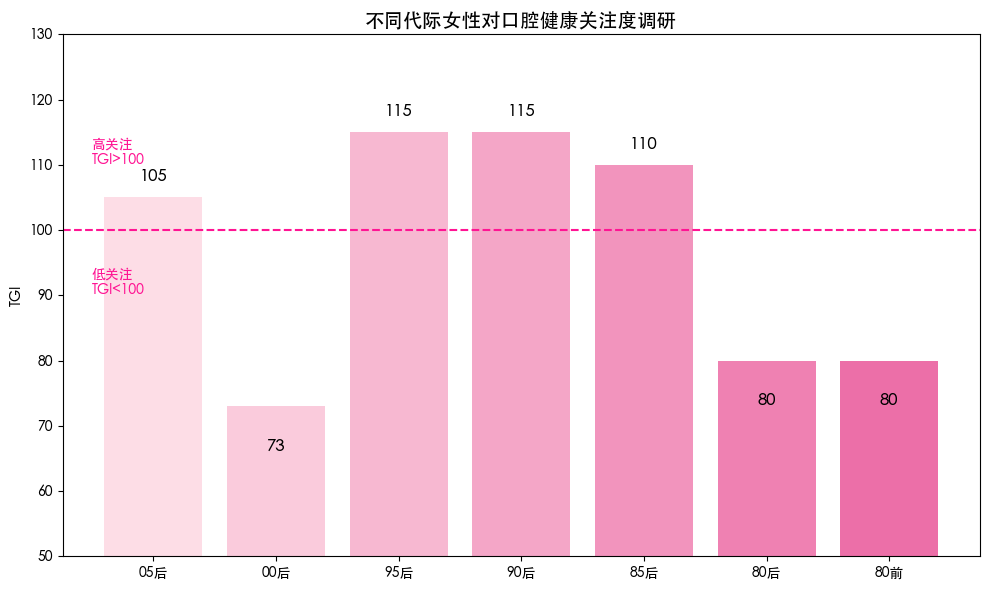

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# 数据
labels = ['05后', '00后', '95后', '90后', '85后', '80后', '80前']
values = [105, 73, 115, 115, 110, 80, 80]

# 颜色设置：浅粉 -> 深粉 渐变
cmap = mcolors.LinearSegmentedColormap.from_list("pink_gradient", ["#fddde6", "#ec6fa8"])
colors = [cmap(i / (len(values) - 1)) for i in range(len(values))]

# 绘图
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)

# 辅助线和标注
ax.axhline(100, color='deeppink', linestyle='--', linewidth=1.5)
for bar, val in zip(bars, values):
    va = 'bottom' if val >= 100 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2, val + (2 if val >= 100 else -5), f'{val}',
            ha='center', va=va, fontsize=12, color='black')

# 标题和说明
ax.set_title('不同代际女性对口腔健康关注度调研', fontsize=14)
ax.set_ylabel('TGI')
ax.set_ylim(50, 130)
ax.text(-0.5, 110, '高关注\nTGI>100', color='deeppink', fontsize=10)
ax.text(-0.5, 90, '低关注\nTGI<100', color='deeppink', fontsize=10)

plt.tight_layout()
plt.show()


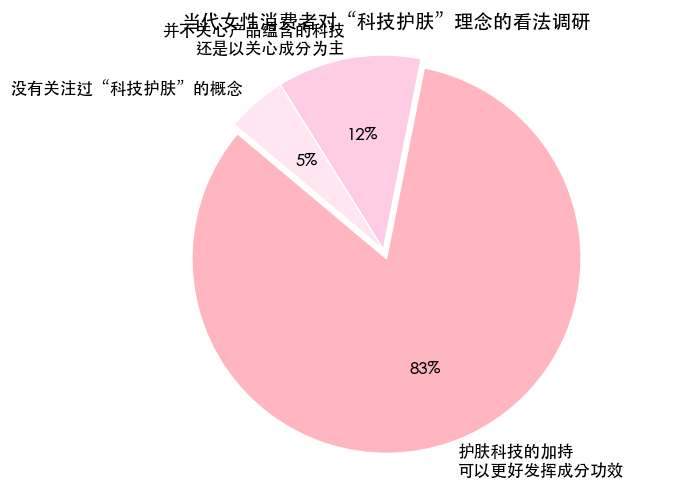

In [13]:
import matplotlib.pyplot as plt

# 数据
labels = [
    "护肤科技的加持\n可以更好发挥成分功效",
    "并不关心产品蕴含的科技\n还是以关心成分为主",
    "没有关注过“科技护肤”的概念"
]
sizes = [83, 12, 5]
colors = ['#FFB6C1', '#FFCCE5', '#FFE6F0']  # 粉色系渐变
explode = (0.05, 0, 0)  # 突出第一块

# 绘图
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.0f%%',
    startangle=140,
    textprops={'fontsize': 12},
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)

ax.axis('equal')  # 保证饼图为圆形
plt.title("当代女性消费者对“科技护肤”理念的看法调研", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


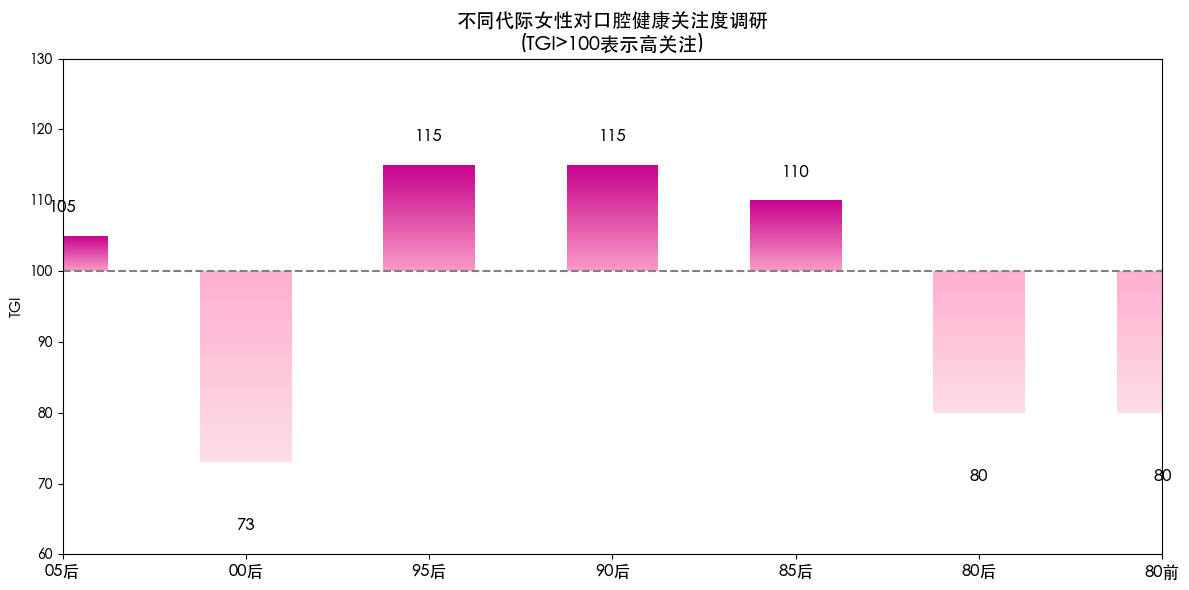

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap

# 数据
generations = ['05后', '00后', '95后', '90后', '85后', '80后', '80前']
values = [105, 73, 115, 115, 110, 80, 80]

# 渐变色生成函数
def gradient_rect(ax, x, y, width, height, color1, color2, vertical=True):
    cmap = LinearSegmentedColormap.from_list("custom_gradient", [color1, color2])
    n = 100
    for i in range(n):
        if vertical:
            yi = y + i * height / n
            hi = height / n
            rect = Rectangle((x, yi), width, hi, color=cmap(i / n), linewidth=0)
        else:
            xi = x + i * width / n
            wi = width / n
            rect = Rectangle((xi, y), wi, height, color=cmap(i / n), linewidth=0)
        ax.add_patch(rect)

# 创建图表
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.5
x = np.arange(len(generations))

# 绘制渐变柱状图
for i, val in enumerate(values):
    if val >= 100:
        gradient_rect(ax, x[i] - bar_width / 2, 100, bar_width, val - 100, '#f99bc5', '#c7008d', vertical=True)
    else:
        gradient_rect(ax, x[i] - bar_width / 2, val, bar_width, 100 - val, '#fddde6', '#fdaecf', vertical=True)

# 添加辅助线和文本
ax.axhline(100, color='gray', linestyle='--')
for i, v in enumerate(values):
    va = -10 if v < 100 else 5
    ax.text(x[i], v + va, str(v), color='black', ha='center', va='bottom' if v < 100 else 'top', fontsize=12)

# 设置轴标签
ax.set_xticks(x)
ax.set_xticklabels(generations, fontsize=12)
ax.set_ylabel('TGI')
ax.set_ylim(60, 130)
ax.set_title('不同代际女性对口腔健康关注度调研\n(TGI>100表示高关注)', fontsize=14)

# 显示图表
plt.tight_layout()
plt.show()


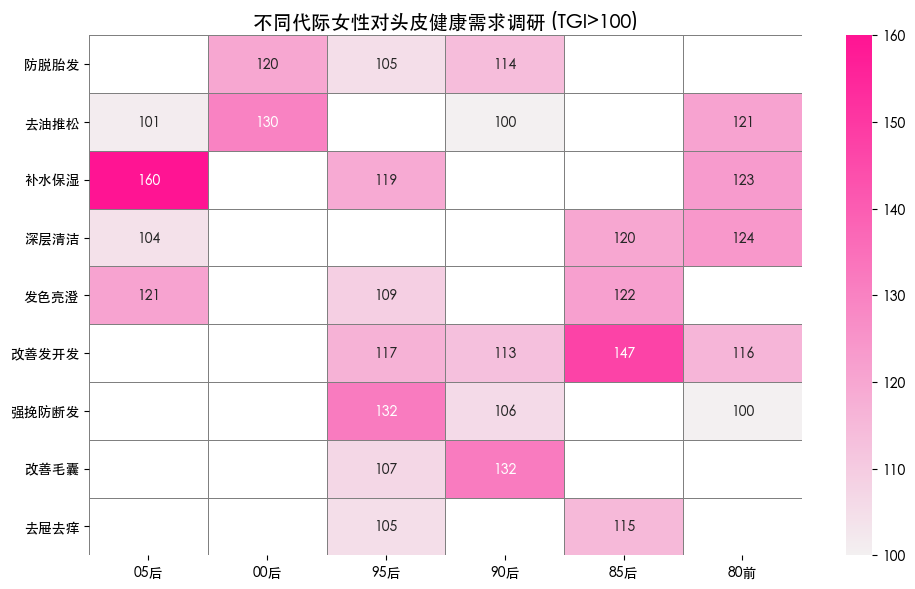

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 数据
labels = ["防脱胎发", "去油推松", "补水保湿", "深层清洁", "发色亮澄",
          "改善发开发", "强挽防断发", "改善毛囊", "去屉去痒"]
columns = ["05后", "00后", "95后", "90后", "85后", "80前"]
data = [
    [96, 120, 105, 114, 95, 49],
    [101, 130, 82, 100, 96, 121],
    [160, 88, 119, 90, 58, 123],
    [104, 95, 72, 96, 120, 124],
    [121, 93, 109, 67, 122, 87],
    [78, 43, 117, 113, 147, 116],
    [45, 74, 132, 106, 85, 100],
    [95, 78, 107, 132, 60, 85],
    [85, 93, 105, 96, 115, 98]
]

# 创建 DataFrame
df = pd.DataFrame(data, index=labels, columns=columns)

# 设置低于100为白色
masked_df = df.copy()
masked_df[df < 100] = np.nan

# 选择色系
cmap = sns.light_palette("deeppink", as_cmap=True)

# 绘制热力图
plt.figure(figsize=(10, 6))
sns.heatmap(masked_df, annot=df, fmt="d", cmap=cmap, linewidths=0.5, linecolor='grey', cbar=True,
            mask=df < 100, annot_kws={"size": 10}, square=False)

# 设置标题和样式
plt.title("不同代际女性对头皮健康需求调研 (TGI>100)", fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
